In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")

In [2]:
from src.misc import multi_crx, get_state, count_gates
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import state_fidelity
import numpy as np

## Same Target Qubit

### Fully Disjoint Control Patterns

<IPython.core.display.Latex object>

Number of CX gates: 16
Number of U3 gates: 17


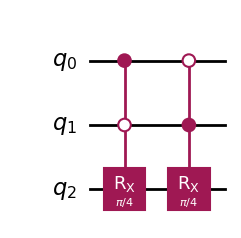

In [3]:
theta = np.pi / 4
qc = QuantumCircuit(3)
rx1 = multi_crx(theta, '10')
rx2 = multi_crx(theta, '01')
qc.append(rx1, [0,1,2])
qc.append(rx2, [0,1,2])

state = get_state(qc)
display(state.draw('latex'))
cx_count, u3_count = count_gates(qc)
print(f"Number of CX gates: {cx_count}")
print(f"Number of U3 gates: {u3_count}")
qc.draw('mpl')

<IPython.core.display.Latex object>

Number of CX gates: 4
Number of U3 gates: 3


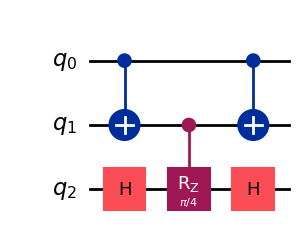

In [4]:
qc_simplified = QuantumCircuit(3)
qc_simplified.h(2)
qc_simplified.cx(0, 1)
qc_simplified.crz(theta, 1, 2)
qc_simplified.cx(0, 1)
qc_simplified.h(2)

state_simplified = get_state(qc_simplified)
display(state_simplified.draw('latex'))
cx_count_simplified, u3_count_simplified = count_gates(qc_simplified)
print(f"Number of CX gates: {cx_count_simplified}")
print(f"Number of U3 gates: {u3_count_simplified}")
qc_simplified.draw('mpl')

In [5]:
fid = state_fidelity(state, state_simplified)
print(f'The fidelity between the two states: {fid:.2f}')

gate_diff_cx = cx_count - cx_count_simplified
gate_diff_u3 = u3_count - u3_count_simplified
print(f'The difference in CX gates: {gate_diff_cx} with percentage {gate_diff_cx / cx_count * 100 if cx_count > 0 else 0:.2f}%')
print(f'The difference in U3 gates: {gate_diff_u3} with percentage {gate_diff_u3 / u3_count * 100 if u3_count > 0 else 0:.2f}%')

The fidelity between the two states: 1.00
The difference in CX gates: 12 with percentage 75.00%
The difference in U3 gates: 14 with percentage 82.35%


### Partially Overlapping Control Patterns

<IPython.core.display.Latex object>

Number of CX gates: 16
Number of U3 gates: 15


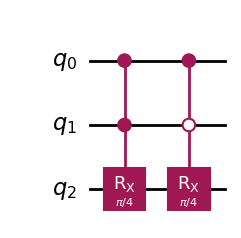

In [6]:
theta = np.pi / 4
qc = QuantumCircuit(3)
rx1 = multi_crx(theta, '11')
rx2 = multi_crx(theta, '10')
qc.append(rx1, [0,1,2])
qc.append(rx2, [0,1,2])

state = get_state(qc)
display(state.draw('latex'))
cx_count, u3_count = count_gates(qc)
print(f"Number of CX gates: {cx_count}")
print(f"Number of U3 gates: {u3_count}")
qc.draw('mpl')

<IPython.core.display.Latex object>

Number of CX gates: 2
Number of U3 gates: 3


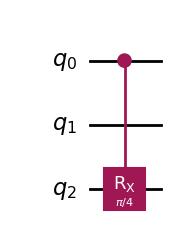

In [7]:
qc_simplified = QuantumCircuit(3)
qc_simplified.crx(theta, 0, 2)

state_simplified = get_state(qc_simplified)
display(state_simplified.draw('latex'))
cx_count_simplified, u3_count_simplified = count_gates(qc_simplified)
print(f"Number of CX gates: {cx_count_simplified}")
print(f"Number of U3 gates: {u3_count_simplified}")
qc_simplified.draw('mpl')

In [8]:
fid = state_fidelity(state, state_simplified)
print(f'The fidelity between the two states: {fid:.2f}')

gate_diff_cx = cx_count - cx_count_simplified
gate_diff_u3 = u3_count - u3_count_simplified
print(f'The difference in CX gates: {gate_diff_cx} with percentage {gate_diff_cx / cx_count * 100 if cx_count > 0 else 0:.2f}%')
print(f'The difference in U3 gates: {gate_diff_u3} with percentage {gate_diff_u3 / u3_count * 100 if u3_count > 0 else 0:.2f}%')

The fidelity between the two states: 1.00
The difference in CX gates: 14 with percentage 87.50%
The difference in U3 gates: 12 with percentage 80.00%


<IPython.core.display.Latex object>

Number of CX gates: 40
Number of U3 gates: 33


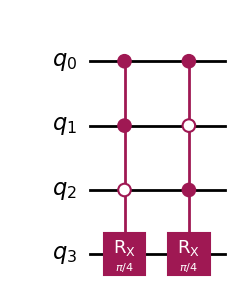

In [9]:
theta = np.pi / 4
qc = QuantumCircuit(4)
rx1 = multi_crx(theta, '110')
rx2 = multi_crx(theta, '101')
qc.append(rx1, [0,1,2,3])
qc.append(rx2, [0,1,2,3])

state = get_state(qc)
display(state.draw('latex'))
cx_count, u3_count = count_gates(qc)
print(f"Number of CX gates: {cx_count}")
print(f"Number of U3 gates: {u3_count}")
qc.draw('mpl')

<IPython.core.display.Latex object>

Number of CX gates: 10
Number of U3 gates: 10


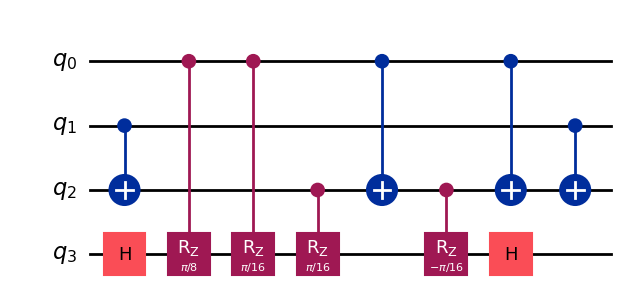

In [10]:
qc_simplified = QuantumCircuit(4)
qc_simplified.h(3)
qc_simplified.crz(theta/2, 0, 3)
qc_simplified.cx(1,2)
qc_simplified.crz(theta/4, 0, 3)
qc_simplified.crz(theta/4, 2, 3)
qc_simplified.cx(0,2)
qc_simplified.crz(-theta/4, 2, 3)
qc_simplified.cx(0,2)
qc_simplified.cx(1,2)
qc_simplified.h(3)

state_simplified = get_state(qc_simplified)
display(state_simplified.draw('latex'))
cx_count_simplified, u3_count_simplified = count_gates(qc_simplified)
print(f"Number of CX gates: {cx_count_simplified}")
print(f"Number of U3 gates: {u3_count_simplified}")
qc_simplified.draw('mpl')

In [11]:
fid = state_fidelity(state, state_simplified)
print(f'The fidelity between the two states: {fid:.2f}')

gate_diff_cx = cx_count - cx_count_simplified
gate_diff_u3 = u3_count - u3_count_simplified
print(f'The difference in CX gates: {gate_diff_cx} with percentage {gate_diff_cx / cx_count * 100 if cx_count > 0 else 0:.2f}%')
print(f'The difference in U3 gates: {gate_diff_u3} with percentage {gate_diff_u3 / u3_count * 100 if u3_count > 0 else 0:.2f}%')

The fidelity between the two states: 0.99
The difference in CX gates: 30 with percentage 75.00%
The difference in U3 gates: 23 with percentage 69.70%


this circuit does not simplfy further

### Subset Control Patterns

<IPython.core.display.Latex object>

Number of CX gates: 8
Number of U3 gates: 10


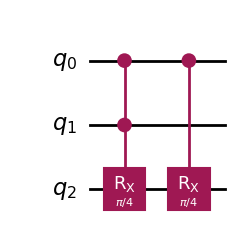

In [12]:
theta = np.pi / 4
qc = QuantumCircuit(3)
rx1 = multi_crx(theta, '11')
qc.append(rx1, [0,1,2])
qc.crx(theta, 0, 2)

state = get_state(qc)
display(state.draw('latex'))
cx_count, u3_count = count_gates(qc)
print(f"Number of CX gates: {cx_count}")
print(f"Number of U3 gates: {u3_count}")
qc.draw('mpl')

<IPython.core.display.Latex object>

Number of CX gates: 8
Number of U3 gates: 10


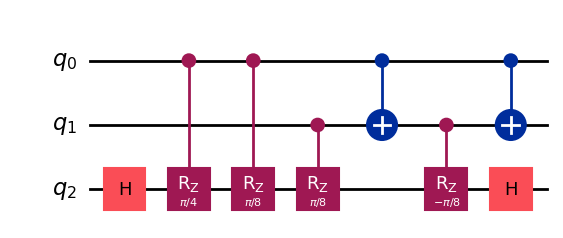

In [13]:
qc_simplified = QuantumCircuit(3)
qc_simplified.h(2)
qc_simplified.crz(theta, 0, 2)
qc_simplified.crz(theta/2, 0, 2)
qc_simplified.crz(theta/2, 1, 2)
qc_simplified.cx(0, 1)
qc_simplified.crz(-theta/2, 1, 2)
qc_simplified.cx(0, 1)
qc_simplified.h(2)

state_simplified = get_state(qc_simplified)
display(state_simplified.draw('latex'))
cx_count_simplified, u3_count_simplified = count_gates(qc_simplified)
print(f"Number of CX gates: {cx_count_simplified}")
print(f"Number of U3 gates: {u3_count_simplified}")
qc_simplified.draw('mpl')

In [14]:
fid = state_fidelity(state, state_simplified)
print(f'The fidelity between the two states: {fid:.2f}')

gate_diff_cx = cx_count - cx_count_simplified
gate_diff_u3 = u3_count - u3_count_simplified
print(f'The difference in CX gates: {gate_diff_cx} with percentage {gate_diff_cx / cx_count * 100 if cx_count > 0 else 0:.2f}%')
print(f'The difference in U3 gates: {gate_diff_u3} with percentage {gate_diff_u3 / u3_count * 100 if u3_count > 0 else 0:.2f}%')

The fidelity between the two states: 1.00
The difference in CX gates: 0 with percentage 0.00%
The difference in U3 gates: 0 with percentage 0.00%


no simplification happens

### Identical Control Patterns

<IPython.core.display.Latex object>

Number of CX gates: 40
Number of U3 gates: 31


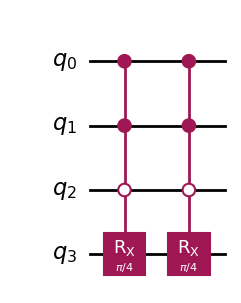

In [15]:
theta = np.pi / 4
qc = QuantumCircuit(4)
rx1 = multi_crx(theta, '110')
rx2 = multi_crx(theta, '110')
qc.append(rx1, [0,1,2,3])
qc.append(rx2, [0,1,2,3])

state = get_state(qc)
display(state.draw('latex'))
cx_count, u3_count = count_gates(qc)
print(f"Number of CX gates: {cx_count}")
print(f"Number of U3 gates: {u3_count}")
qc.draw('mpl')

<IPython.core.display.Latex object>

Number of CX gates: 20
Number of U3 gates: 17


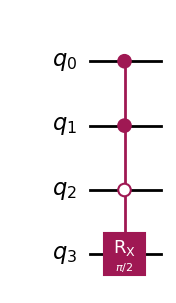

In [16]:
qc_simplified = QuantumCircuit(4)
rx1 = multi_crx(2*theta, '110')
qc_simplified.append(rx1, [0,1,2,3])


state_simplified = get_state(qc_simplified)
display(state_simplified.draw('latex'))
cx_count_simplified, u3_count_simplified = count_gates(qc_simplified)
print(f"Number of CX gates: {cx_count_simplified}")
print(f"Number of U3 gates: {u3_count_simplified}")
qc_simplified.draw('mpl')

In [17]:
fid = state_fidelity(state, state_simplified)
print(f'The fidelity between the two states: {fid:.2f}')

gate_diff_cx = cx_count - cx_count_simplified
gate_diff_u3 = u3_count - u3_count_simplified
print(f'The difference in CX gates: {gate_diff_cx} with percentage {gate_diff_cx / cx_count * 100 if cx_count > 0 else 0:.2f}%')
print(f'The difference in U3 gates: {gate_diff_u3} with percentage {gate_diff_u3 / u3_count * 100 if u3_count > 0 else 0:.2f}%')

The fidelity between the two states: 1.00
The difference in CX gates: 20 with percentage 50.00%
The difference in U3 gates: 14 with percentage 45.16%


## Different Target Qubit

###  Complementary Control Patterns

<IPython.core.display.Latex object>

Number of CX gates: 16
Number of U3 gates: 16


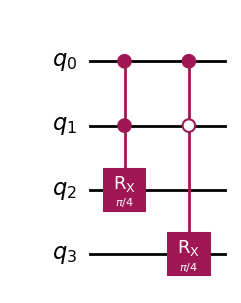

In [18]:
theta = np.pi / 4
qc = QuantumCircuit(4)
rx1 = multi_crx(theta, '11')
rx2 = multi_crx(theta, '10')
qc.append(rx1, [0,1,2])
qc.append(rx2, [0,1,3])

state = get_state(qc)
display(state.draw('latex'))
cx_count, u3_count = count_gates(qc)
print(f"Number of CX gates: {cx_count}")
print(f"Number of U3 gates: {u3_count}")
qc.draw('mpl')

<IPython.core.display.Latex object>

Number of CX gates: 6
Number of U3 gates: 6


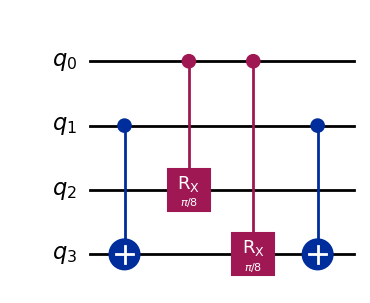

In [19]:
qc_simplified = QuantumCircuit(4)
qc_simplified.cx(1, 3)
qc_simplified.crx(theta/2, 0, 2)
qc_simplified.crx(theta/2, 0, 3)
qc_simplified.cx(1, 3)

state_simplified = get_state(qc_simplified)
display(state_simplified.draw('latex'))
cx_count_simplified, u3_count_simplified = count_gates(qc_simplified)
print(f"Number of CX gates: {cx_count_simplified}")
print(f"Number of U3 gates: {u3_count_simplified}")
qc_simplified.draw('mpl')

In [20]:
fid = state_fidelity(state, state_simplified)
print(f'The fidelity between the two states: {fid:.2f}')

gate_diff_cx = cx_count - cx_count_simplified
gate_diff_u3 = u3_count - u3_count_simplified
print(f'The difference in CX gates: {gate_diff_cx} with percentage {gate_diff_cx / cx_count * 100 if cx_count > 0 else 0:.2f}%')
print(f'The difference in U3 gates: {gate_diff_u3} with percentage {gate_diff_u3 / u3_count * 100 if u3_count > 0 else 0:.2f}%')

The fidelity between the two states: 1.00
The difference in CX gates: 10 with percentage 62.50%
The difference in U3 gates: 10 with percentage 62.50%


### Orthogonal Control Patterns

<IPython.core.display.Latex object>

Number of CX gates: 16
Number of U3 gates: 18


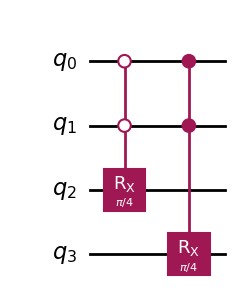

In [21]:
theta = np.pi / 4
qc = QuantumCircuit(4)
rx1 = multi_crx(theta, '00')
rx2 = multi_crx(theta, '11')
qc.append(rx1, [0,1,2])
qc.append(rx2, [0,1,3])

state = get_state(qc)
display(state.draw('latex'))
cx_count, u3_count = count_gates(qc)
print(f"Number of CX gates: {cx_count}")
print(f"Number of U3 gates: {u3_count}")
qc.draw('mpl')

<IPython.core.display.Latex object>

Number of CX gates: 8
Number of U3 gates: 14


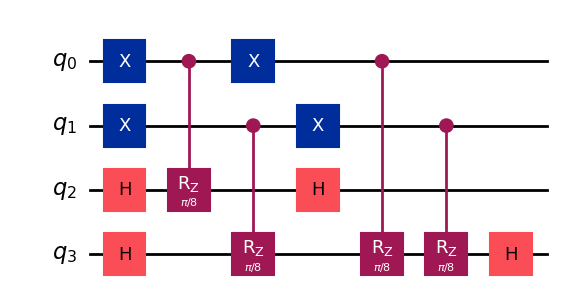

In [22]:
qc_simplified = QuantumCircuit(4)
qc_simplified.x(0)
qc_simplified.x(1)
qc_simplified.h(2)
qc_simplified.h(3)

qc_simplified.crz(theta/2, 0, 2)
qc_simplified.crz(theta/2, 1, 3)

qc_simplified.x(0)
qc_simplified.x(1)

qc_simplified.crz(theta/2, 0, 3)
qc_simplified.crz(theta/2, 1, 3)

qc_simplified.h(2)
qc_simplified.h(3)

state_simplified = get_state(qc_simplified)
display(state_simplified.draw('latex'))
cx_count_simplified, u3_count_simplified = count_gates(qc_simplified)
print(f"Number of CX gates: {cx_count_simplified}")
print(f"Number of U3 gates: {u3_count_simplified}")
qc_simplified.draw('mpl')

In [23]:
fid = state_fidelity(state, state_simplified)
print(f'The fidelity between the two states: {fid:.2f}')

gate_diff_cx = cx_count - cx_count_simplified
gate_diff_u3 = u3_count - u3_count_simplified
print(f'The difference in CX gates: {gate_diff_cx} with percentage {gate_diff_cx / cx_count * 100 if cx_count > 0 else 0:.2f}%')
print(f'The difference in U3 gates: {gate_diff_u3} with percentage {gate_diff_u3 / u3_count * 100 if u3_count > 0 else 0:.2f}%')

The fidelity between the two states: 0.96
The difference in CX gates: 8 with percentage 50.00%
The difference in U3 gates: 4 with percentage 22.22%


### Overlapping Control Patterns

<IPython.core.display.Latex object>

Number of CX gates: 10
Number of U3 gates: 10


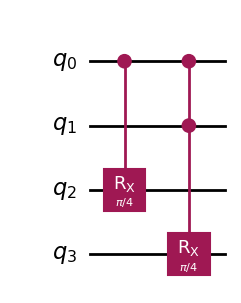

In [24]:
theta = np.pi / 4
qc = QuantumCircuit(4)
rx2 = multi_crx(theta, '11')
qc.crx(theta, 0, 2)
qc.append(rx2, [0,1,3])

state = get_state(qc)
display(state.draw('latex'))
cx_count, u3_count = count_gates(qc)
print(f"Number of CX gates: {cx_count}")
print(f"Number of U3 gates: {u3_count}")
qc.draw('mpl')

<IPython.core.display.Latex object>

Number of CX gates: 10
Number of U3 gates: 10


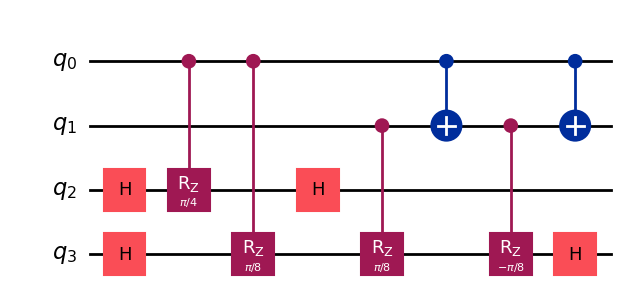

In [25]:
qc_simplified = QuantumCircuit(4)

qc_simplified.h(2)
qc_simplified.h(3)

qc_simplified.crz(theta, 0, 2)
qc_simplified.crz(theta/2, 0, 3)
qc_simplified.crz(theta/2, 1, 3)

qc_simplified.cx(0, 1)

qc_simplified.crz(-theta/2, 1, 3)
qc_simplified.cx(0, 1)

qc_simplified.h(2)
qc_simplified.h(3)


state_simplified = get_state(qc_simplified)
display(state_simplified.draw('latex'))
cx_count_simplified, u3_count_simplified = count_gates(qc_simplified)
print(f"Number of CX gates: {cx_count_simplified}")
print(f"Number of U3 gates: {u3_count_simplified}")
qc_simplified.draw('mpl')

In [26]:
fid = state_fidelity(state, state_simplified)
print(f'The fidelity between the two states: {fid:.2f}')

gate_diff_cx = cx_count - cx_count_simplified
gate_diff_u3 = u3_count - u3_count_simplified
print(f'The difference in CX gates: {gate_diff_cx} with percentage {gate_diff_cx / cx_count * 100 if cx_count > 0 else 0:.2f}%')
print(f'The difference in U3 gates: {gate_diff_u3} with percentage {gate_diff_u3 / u3_count * 100 if u3_count > 0 else 0:.2f}%')

The fidelity between the two states: 1.00
The difference in CX gates: 0 with percentage 0.00%
The difference in U3 gates: 0 with percentage 0.00%


### Identical Multi-Control Patterns

<IPython.core.display.Latex object>

Number of CX gates: 40
Number of U3 gates: 32


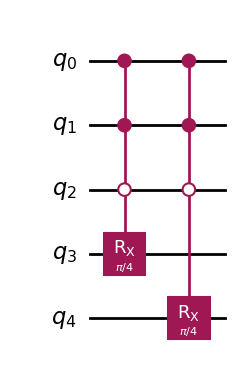

In [27]:
theta = np.pi / 4
qc = QuantumCircuit(5)
rx1 = multi_crx(theta, '110')
rx2 = multi_crx(theta, '110')
qc.append(rx1, [0,1,2,3])
qc.append(rx2, [0,1,2,4])

state = get_state(qc)
display(state.draw('latex'))
cx_count, u3_count = count_gates(qc)
print(f"Number of CX gates: {cx_count}")
print(f"Number of U3 gates: {u3_count}")
qc.draw('mpl')

<IPython.core.display.Latex object>

Number of CX gates: 24
Number of U3 gates: 22


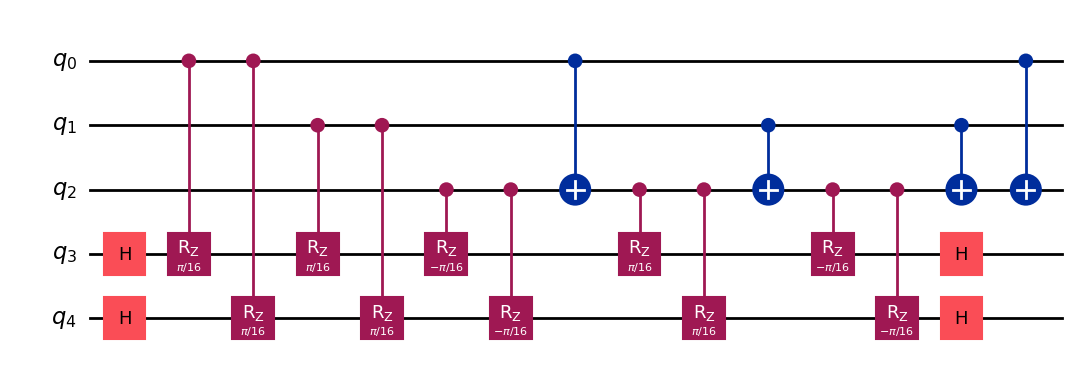

In [28]:
qc_simplified = QuantumCircuit(5)

qc_simplified.h(3)
qc_simplified.h(4)

qc_simplified.crz(theta/4, 0, 3)
qc_simplified.crz(theta/4, 0, 4)

qc_simplified.crz(theta/4, 1, 3)
qc_simplified.crz(theta/4, 1, 4)

qc_simplified.crz(-theta/4, 2, 3)
qc_simplified.crz(-theta/4, 2, 4)

qc_simplified.cx(0, 2)

qc_simplified.crz(theta/4, 2, 3)
qc_simplified.crz(theta/4, 2, 4)

qc_simplified.cx(1, 2)

qc_simplified.crz(-theta/4, 2, 3)
qc_simplified.crz(-theta/4, 2, 4)

qc_simplified.cx(1, 2)
qc_simplified.cx(0, 2)

qc_simplified.h(3)
qc_simplified.h(4)

state_simplified = get_state(qc_simplified)
display(state_simplified.draw('latex'))
cx_count_simplified, u3_count_simplified = count_gates(qc_simplified)
print(f"Number of CX gates: {cx_count_simplified}")
print(f"Number of U3 gates: {u3_count_simplified}")
qc_simplified.draw('mpl')

In [29]:
fid = state_fidelity(state, state_simplified)
print(f'The fidelity between the two states: {fid:.2f}')

gate_diff_cx = cx_count - cx_count_simplified
gate_diff_u3 = u3_count - u3_count_simplified
print(f'The difference in CX gates: {gate_diff_cx} with percentage {gate_diff_cx / cx_count * 100 if cx_count > 0 else 0:.2f}%')
print(f'The difference in U3 gates: {gate_diff_u3} with percentage {gate_diff_u3 / u3_count * 100 if u3_count > 0 else 0:.2f}%')

The fidelity between the two states: 0.98
The difference in CX gates: 16 with percentage 40.00%
The difference in U3 gates: 10 with percentage 31.25%
